In [1]:
%load_ext autoreload
%reload_ext autoreload

%autoreload 2
%matplotlib inline
import tensorflow
from tensorflow.compat.v1.keras.backend import get_session
tensorflow.compat.v1.disable_v2_behavior()
import kerasAC 
from kerasAC.generators.tiledb_predict_generator import *
from kerasAC.tiledb_config import *
import tiledb 
from scipy.special import softmax
from kerasAC.interpret.deepshap import * 
from kerasAC.interpret.profile_shap import * 
from kerasAC.vis import * 

Instructions for updating:
non-resource variables are not supported in the long term


Using TensorFlow backend.
/users/annashch/kerasAC/kerasAC/vis/plot_letters.py:173: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  min_coords = np.vstack(data.min(0) for data in polygons_data).min(0)
/users/annashch/kerasAC/kerasAC/vis/plot_letters.py:174: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  max_coords = np.vstack(data.max(0) for data in polygons_data).max(0)


In [2]:
## for plotting 
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5
plt.rcParams['axes.xmargin'] = 0

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

In [3]:
import pickle 
baseline=pickle.load(open("K562.DNASE.baseline.fold0.deepSHAP",'rb'))

In [4]:
corrected=pickle.load(open("K562.DNASE.bias_corrected_bpnet_tobias.fold0.deepSHAP",'rb'))

In [5]:
unplugged=pickle.load(open("K562.DNASE.bias_corrected_bpnet_tobias.unplugged.fold0.deepSHAP",'rb'))

In [7]:
## get distribution of JSD & MNNLL
dist=pd.read_csv("/srv/scratch/annashch/deeplearning/profile/vis_bias_cor/jsd_mnll/k562.dnase.jsd.txt",header=0,sep='\t')

In [8]:
dist["correct_minus_baseline"]=dist['bpnet.tobias']-dist['baseline']

In [9]:
dist.head()

,chrom,summit,bpnet.tobias,tobias,bpnet,baseline,correct_minus_baseline
0,chr1,1000190,0.141122,0.142548,0.185089,0.120471,0.020651
1,chr1,100028978,0.187314,0.179491,0.233281,0.227844,-0.040530
2,chr1,100029186,0.227073,0.201553,0.358012,0.223351,0.003722
3,chr1,100036936,0.247901,0.183648,0.226887,0.142072,0.105829
4,chr1,100038045,0.125997,0.150557,0.115295,0.205898,-0.079901


In [10]:
#remove mnnll scores in top quantile 
thresh=dist.quantile(0.8)


In [11]:
good_scores=dist[dist['bpnet.tobias']<thresh['bpnet.tobias']]
good_scores=good_scores[good_scores['baseline']<thresh['baseline']]


In [12]:
good_scores

,chrom,summit,bpnet.tobias,tobias,bpnet,baseline,correct_minus_baseline
0,chr1,1000190,0.141122,0.142548,0.185089,0.120471,0.020651
1,chr1,100028978,0.187314,0.179491,0.233281,0.227844,-0.040530
2,chr1,100029186,0.227073,0.201553,0.358012,0.223351,0.003722
3,chr1,100036936,0.247901,0.183648,0.226887,0.142072,0.105829
4,chr1,100038045,0.125997,0.150557,0.115295,0.205898,-0.079901
...,...,...,...,...,...,...,...
78393,chr6,99568429,0.160255,0.165344,0.164303,0.193069,-0.032813
78394,chr6,99568711,0.165568,0.139631,0.130488,0.191825,-0.026257
78395,chr6,99575718,0.163422,0.134123,0.139518,0.170219,-0.006796
78398,chr6,99603821,0.243974,0.193555,0.223702,0.205735,0.038239


In [13]:
max(good_scores['baseline'])

0.24990504137998154

In [14]:
max(dist['baseline'])

0.7973582144545861

In [15]:
good_scores.sort_values(by='correct_minus_baseline',inplace=True)

In [16]:
good_scores.head()

,chrom,summit,bpnet.tobias,tobias,bpnet,baseline,correct_minus_baseline
45301,chr2,231482914,0.063906,0.121777,0.149094,0.239593,-0.175686
21211,chr16,67303094,0.070790,0.107275,0.097442,0.244230,-0.173440
64828,chr5,173324273,0.078491,0.140817,0.087987,0.247336,-0.168845
29918,chr19,45717917,0.078733,0.087363,0.122780,0.246924,-0.168191
8856,chr1,227902435,0.079471,0.090299,0.118862,0.247101,-0.167630


In [17]:
good_scores.tail()

,chrom,summit,bpnet.tobias,tobias,bpnet,baseline,correct_minus_baseline
31986,chr19,55212621,0.254984,0.289904,0.312907,0.079136,0.175848
55319,chr3,156555262,0.246695,0.261627,0.263819,0.070190,0.176505
69037,chr6,109483639,0.255621,0.145474,0.203912,0.079097,0.176524
11937,chr13,114004770,0.248645,0.311959,0.289241,0.070462,0.178183
71024,chr6,145734936,0.248633,0.181241,0.232727,0.069942,0.178691


In [18]:
good_scores.reset_index()
good_scores.iloc[0]

chrom                          chr2
summit                    231482914
bpnet.tobias              0.0639063
tobias                     0.121777
bpnet                      0.149094
baseline                   0.239593
correct_minus_baseline    -0.175686
Name: 45301, dtype: object

In [19]:
#region=tuple(['chr2',231482914])

In [20]:
def extract_region(region,interp_dict):
    label_prof=interp_dict['label_prof'][region]
    label_sum=round(interp_dict['label_sum'][region],3)
    pred_prof=interp_dict['pred_prof'][region]
    pred_sum=round(interp_dict['pred_sum'][region],3)
    profile_shap=interp_dict['profile_shap'][region][173:173+1000]
    count_shap=interp_dict['count_shap'][region][173:173+1000]
    seq=interp_dict['seq'][region][173:173+1000]
    profile_shap=profile_shap*seq 
    count_shap=count_shap*seq 
    #get the min & max values, to use in ylims for plotting 
    minval_perf=min([label_prof.min(),pred_prof.min()])
    maxval_perf=max([label_prof.max(),pred_prof.max()])
    minval_shap=min([profile_shap.min(), count_shap.min()])
    maxval_shap=max([profile_shap.max(), count_shap.max()])
    return label_prof, label_sum, pred_prof, pred_sum, profile_shap, count_shap, seq, minval_perf, maxval_perf, minval_shap, maxval_shap

In [21]:
def make_plot(toplot_b,toplot_c,toplot_u,region,ymin_perf,ymax_perf,ymin_shap,ymax_shap,xmin=0,xmax=1000):
    plt.rcParams["figure.figsize"]=15,20
    fig, axes = plt.subplots(9, 1)
    axes[0].plot(toplot_b[0],label='Label Prob',color='b')
    axes[0].plot(toplot_b[2],label='Pred Prob',color='r')
    axes[0].set_title("Baseline K562 DNASE:"+str(region)+"Counts Label:"+str(toplot_b[1])+":"+"Counts Pred:"+str(toplot_b[3]))
    axes[0].legend() 
    axes[0].set_xlim(xmin,xmax)
    axes[0].set_ylim(ymin_perf,ymax_perf)
    axes[0].set_xticks(list(range(xmin, xmax, 50,)))    
    
    axes[1]=plot_seq_importance(toplot_b[4],toplot_b[6],xlim=(xmin,xmax),axes=axes[1])
    axes[1].set_title("Profile Loss SHAP")        
    axes[1].set_ylim(ymin_shap,ymax_shap)
    axes[1].set_xticks(list(range(xmin, xmax, 50,)))    

    axes[2]=plot_seq_importance(toplot_b[5],toplot_b[6],xlim=(xmin,xmax),axes=axes[2])
    axes[2].set_title("Count Loss SHAP")
    axes[2].set_ylim(ymin_shap,ymax_shap)
    axes[2].set_xticks(list(range(xmin, xmax, 50,)))   
    
    axes[3].plot(toplot_c[0],label='Label Prob',color='b')
    axes[3].plot(toplot_c[2],label='Pred Prob',color='r')    
    axes[3].set_title("Corrected K562 DNASE:"+str(region)+"Counts Label:"+str(toplot_c[1])+":"+"Counts Pred:"+str(toplot_c[3]))
    axes[3].legend()
    axes[3].set_xlim(xmin,xmax)
    axes[3].set_ylim(ymin_perf,ymax_perf)
    axes[3].set_xticks(list(range(xmin, xmax, 50,)))
    
    axes[4]=plot_seq_importance(toplot_c[4],toplot_c[6],xlim=(xmin,xmax),axes=axes[4])
    axes[4].set_title("Profile Loss SHAP")
    axes[4].set_ylim(ymin_shap,ymax_shap)
    axes[4].set_xticks(list(range(xmin, xmax, 50,)))
    
    axes[5]=plot_seq_importance(toplot_c[5],toplot_c[6],xlim=(xmin,xmax),axes=axes[5])
    axes[5].set_title("Count Loss SHAP")
    axes[5].set_ylim(ymin_shap,ymax_shap)
    axes[5].set_xticks(list(range(xmin, xmax, 50,)))
    
    axes[6].plot(toplot_u[0],label='Label Prob',color='b')
    axes[6].plot(toplot_u[2],label='Pred Prob',color='r')
    axes[6].set_title("Unplugged K562 DNASE:"+str(region)+"Counts Label:"+str(toplot_u[1])+":"+"Counts Pred:"+str(toplot_u[3]))
    axes[6].legend()
    axes[6].set_xlim(xmin,xmax)
    axes[6].set_ylim(ymin_perf,ymax_perf)
    axes[6].set_xticks(list(range(xmin, xmax, 50,)))
    
    axes[7]=plot_seq_importance(toplot_u[4],toplot_u[6],xlim=(xmin,xmax),axes=axes[7])
    axes[7].set_title("Profile Loss SHAP")
    axes[7].set_ylim(ymin_shap,ymax_shap)
    axes[7].set_xticks(list(range(xmin, xmax, 50,)))
    
    axes[8]=plot_seq_importance(toplot_u[5],toplot_u[6],xlim=(xmin,xmax),axes=axes[8])
    axes[8].set_title("Count Loss SHAP")
    axes[8].set_ylim(ymin_shap,ymax_shap)
    axes[8].set_xticks(list(range(xmin, xmax, 50,)))
    
    
    
    
    plt.subplots_adjust(hspace=0.6)
    plt.show()

In [22]:
[i.shape for i in baseline_region_vals]

NameError: name 'baseline_region_vals' is not defined

('chr1', 227902435)


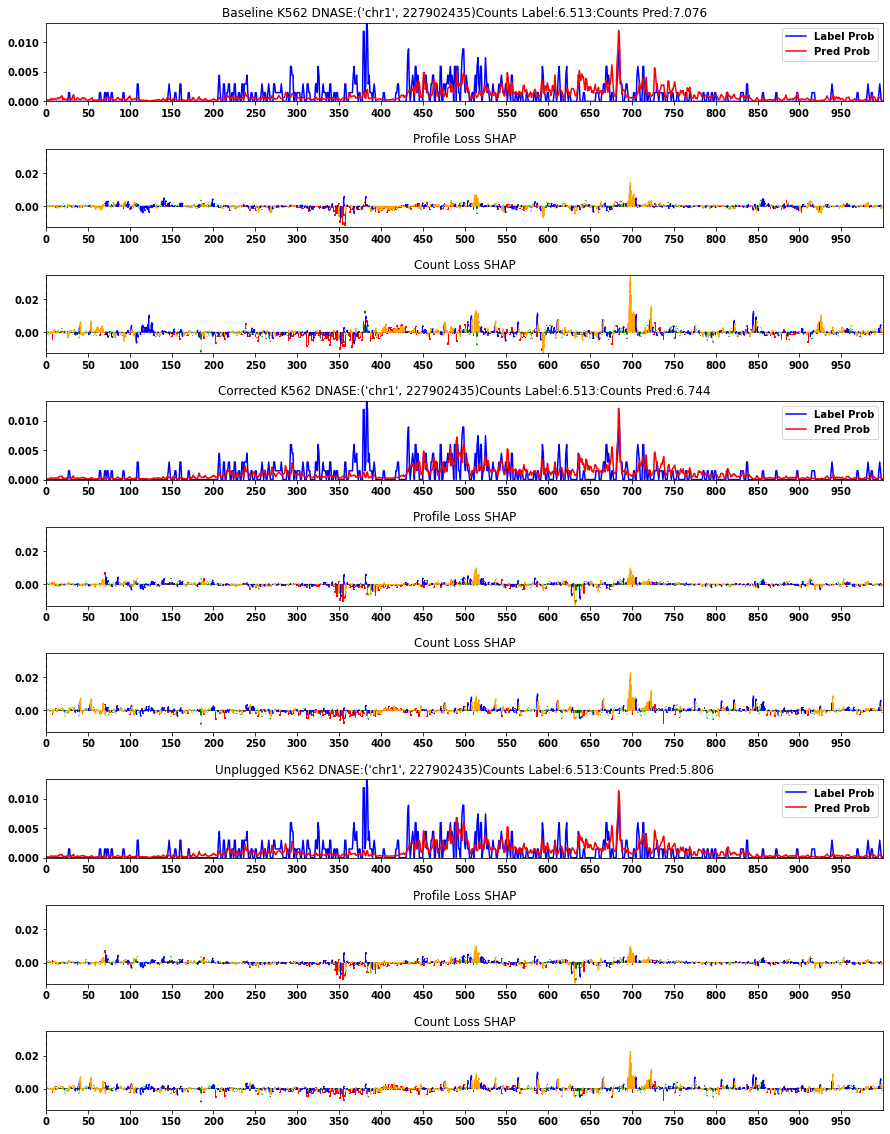

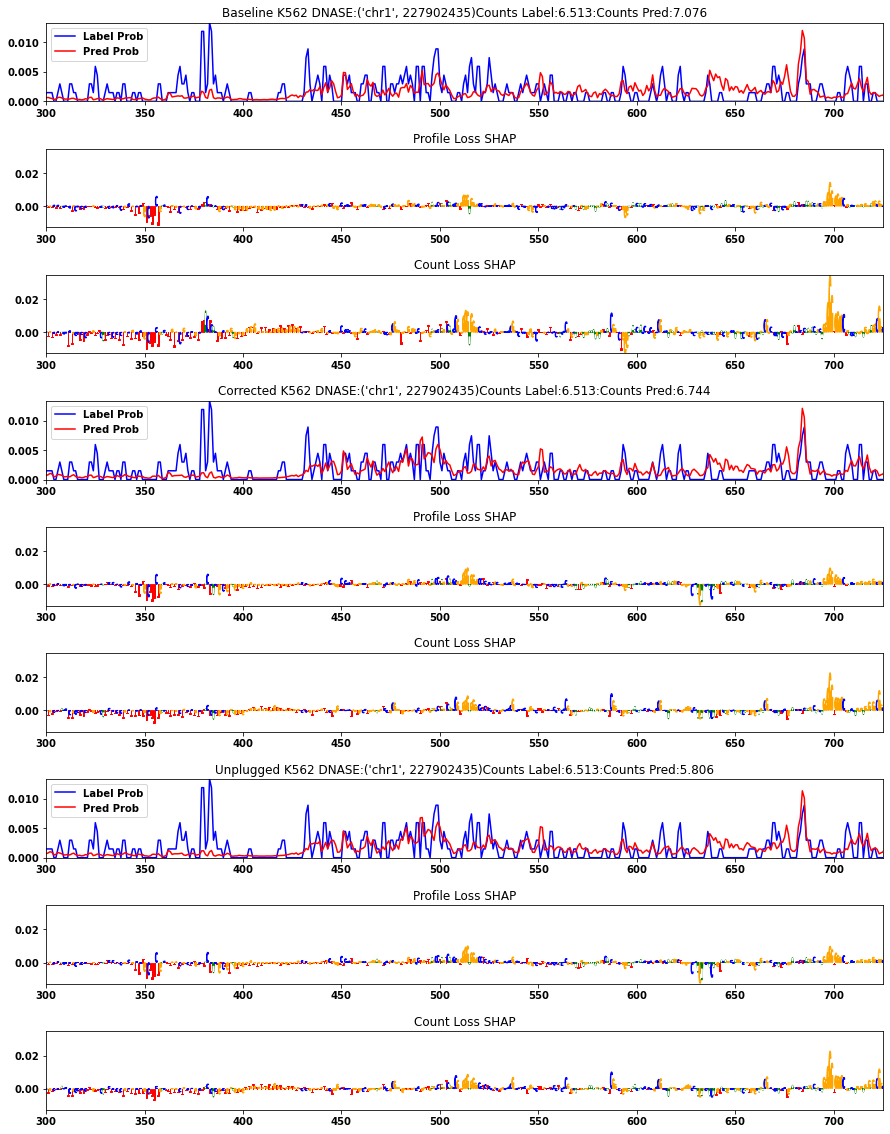

In [149]:
#print the regions where the bias correction cleans up intepretations 
for i in range(4,5): 
    cur_chrom=good_scores.iloc[i]['chrom'] 
    cur_pos=good_scores.iloc[i]['summit']
    region=tuple([cur_chrom,cur_pos])
    print(str(region))
    baseline_region_vals=extract_region(region,baseline)
    corrected_region_vals=extract_region(region,corrected)
    unplugged_region_vals=extract_region(region,unplugged)
    minval_perf=min([baseline_region_vals[7],corrected_region_vals[7], unplugged_region_vals[7]])
    maxval_perf=max([baseline_region_vals[8],corrected_region_vals[8], unplugged_region_vals[8]])
    minval_shap=min([baseline_region_vals[9],corrected_region_vals[9], unplugged_region_vals[9]])
    maxval_shap=max([baseline_region_vals[10],corrected_region_vals[10], unplugged_region_vals[10]])
    make_plot(baseline_region_vals,
        corrected_region_vals, 
        unplugged_region_vals,
        region,
        ymin_perf=minval_perf,
        ymax_perf=maxval_perf,
        ymin_shap=minval_shap,
        ymax_shap=maxval_shap)
    make_plot(baseline_region_vals,
        corrected_region_vals, 
        unplugged_region_vals,
        region,
        ymin_perf=minval_perf,
        ymax_perf=maxval_perf,
        ymin_shap=minval_shap,
        ymax_shap=maxval_shap,
        xmin=300,
        xmax=725)

('chr6', 145734936)


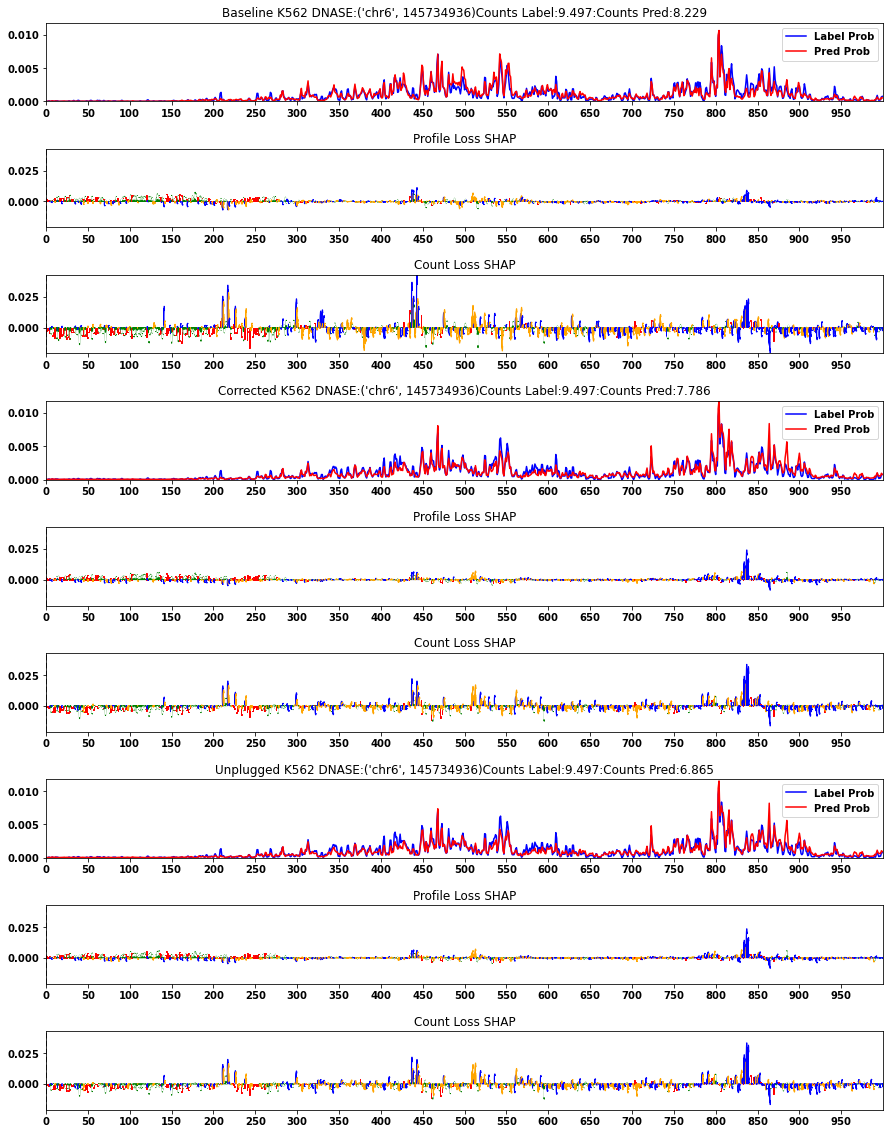

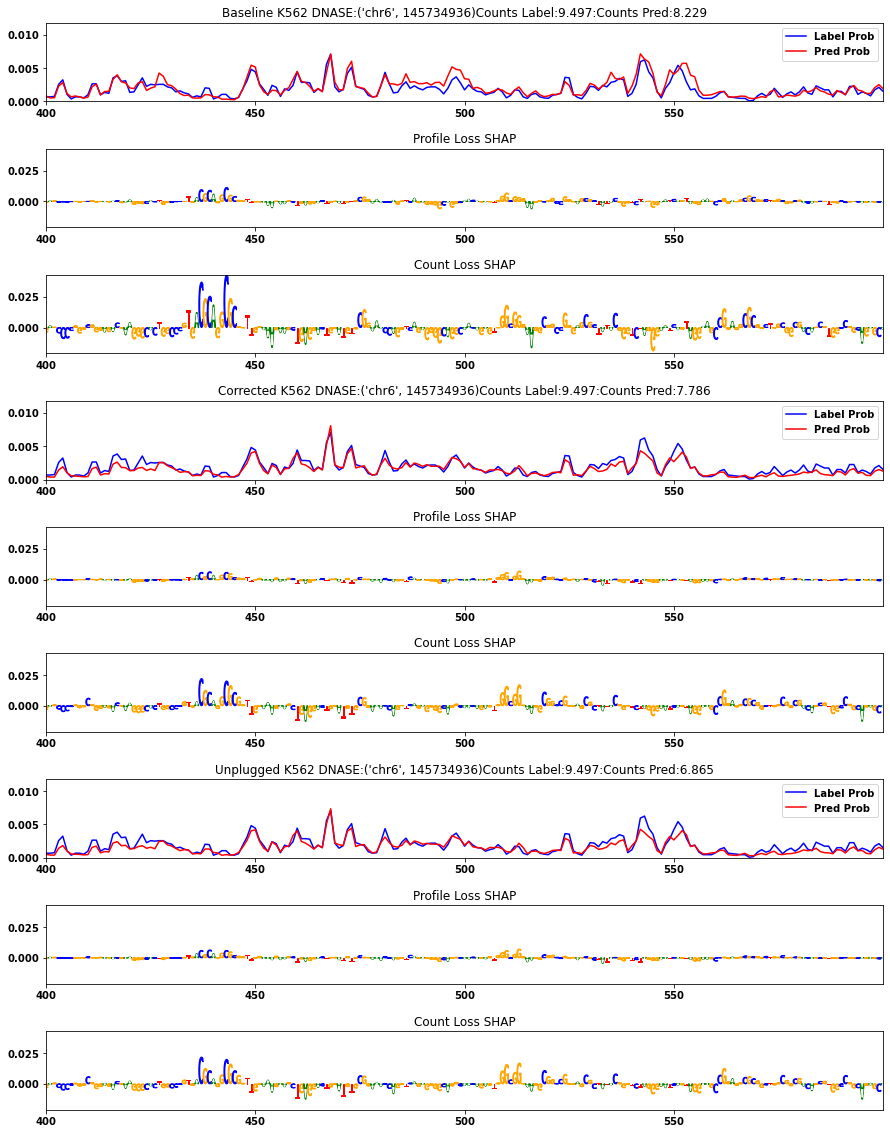

In [158]:
#print the regions where the bias correction cleans up intepretations 
for i in range(52328,52329): 
    cur_chrom=good_scores.iloc[i]['chrom'] 
    cur_pos=good_scores.iloc[i]['summit']
    region=tuple([cur_chrom,cur_pos])
    print(str(region))
    baseline_region_vals=extract_region(region,baseline)
    corrected_region_vals=extract_region(region,corrected)
    unplugged_region_vals=extract_region(region,unplugged)
    minval_perf=min([baseline_region_vals[7],corrected_region_vals[7], unplugged_region_vals[7]])
    maxval_perf=max([baseline_region_vals[8],corrected_region_vals[8], unplugged_region_vals[8]])
    minval_shap=min([baseline_region_vals[9],corrected_region_vals[9], unplugged_region_vals[9]])
    maxval_shap=max([baseline_region_vals[10],corrected_region_vals[10], unplugged_region_vals[10]])
    make_plot(baseline_region_vals,
        corrected_region_vals, 
        unplugged_region_vals,
        region,
        ymin_perf=minval_perf,
        ymax_perf=maxval_perf,
        ymin_shap=minval_shap,
        ymax_shap=maxval_shap)
    make_plot(baseline_region_vals,
        corrected_region_vals, 
        unplugged_region_vals,
        region,
        ymin_perf=minval_perf,
        ymax_perf=maxval_perf,
        ymin_shap=minval_shap,
        ymax_shap=maxval_shap,
        xmin=400,
        xmax=600)

In [150]:
good_scores.shape[0]

52329